In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

def set_seed(seed=42):
    np.random.seed(seed)
set_seed(42)

ratings = pd.read_csv('../data/ml-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
ratings_sorted = ratings.sort_values('timestamp').reset_index(drop=True)
n = len(ratings_sorted)
train_end = int(0.7 * n)
val_end = int(0.8 * n)
train_df = ratings_sorted.iloc[:train_end].copy()
val_df = ratings_sorted.iloc[train_end:val_end].copy()
test_df = ratings_sorted.iloc[val_end:].copy()
global_mean = train_df['rating'].mean()

print(f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}, global_mean={global_mean:.4f}")

train=70000, val=10000, test=20000, global_mean=3.5300


In [2]:
genre_cols = ['unknown','Action','Adventure','Animation','Children','Comedy','Crime',
              'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical','Mystery',
              'Romance','Sci-Fi','Thriller','War','Western']
item_cols = ['item_id','title','release_date','video_date','imdb_url'] + genre_cols
movies = pd.read_csv('../data/ml-100k/u.item', sep='|', names=item_cols, encoding='latin-1')
movies[genre_cols] = movies[genre_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

movies['year'] = pd.to_datetime(movies['release_date'], format='%d-%b-%Y', errors='coerce').dt.year
year_median = movies['year'].median()
movies['year'] = movies['year'].fillna(year_median)

# статистики по train
item_stats = train_df.groupby('item_id')['rating'].agg(['mean','count'])
item_stats.columns = ['item_mean_rating','item_popularity']
user_stats = train_df.groupby('user_id')['rating'].agg(['mean','count'])
user_stats.columns = ['user_mean_rating','user_activity']
item_stats['item_popularity_log'] = np.log1p(item_stats['item_popularity'])
user_stats['user_activity_log']   = np.log1p(user_stats['user_activity'])

# жанровое ожидание для cold-start фильмов
train_with_genres = train_df.merge(movies[['item_id'] + genre_cols], on='item_id', how='left')
genre_mean_rating = {}
for g in genre_cols:
    mask = train_with_genres[g] == 1
    genre_mean_rating[g] = train_with_genres.loc[mask,'rating'].mean() if mask.sum()>0 else global_mean
genre_mean_rating = pd.Series(genre_mean_rating)
def expected_rating_by_genres(row):
    active = [g for g in genre_cols if row[g]==1]
    return np.mean([genre_mean_rating[g] for g in active]) if active else global_mean
movies['genre_expected_rating'] = movies.apply(expected_rating_by_genres, axis=1)

# данные по пользователям
user_cols = ['user_id','age','gender','occupation','zip_code']
users = pd.read_csv('../data/ml-100k/u.user', sep='|', names=user_cols, encoding='latin-1')
users['gender_M'] = (users['gender']=='M').astype(int)
occ_dummies = pd.get_dummies(users['occupation'], prefix='occ').astype(int)
users = pd.concat([users, occ_dummies], axis=1)
demo_cols = ['age','gender_M'] + list(occ_dummies.columns)
users_features = users[['user_id'] + demo_cols]

print("Данные и статистики готовы")

Данные и статистики готовы


In [3]:
def build_features(df): # из 6-ого ноутбука
    d = df.merge(movies[['item_id','year','genre_expected_rating'] + genre_cols], on='item_id', how='left')
    d = d.merge(item_stats, on='item_id', how='left')
    d = d.merge(user_stats, on='user_id', how='left')
    d = d.merge(users_features, on='user_id', how='left')

    d['item_mean_rating'] = d['item_mean_rating'].fillna(d['genre_expected_rating']).fillna(global_mean)
    d['user_mean_rating'] = d['user_mean_rating'].fillna(global_mean)
    for col in ['item_popularity','user_activity','item_popularity_log','user_activity_log']:
        d[col] = d[col].fillna(0)
    d['year'] = d['year'].fillna(year_median)
    for g in genre_cols:
        d[g] = d[g].fillna(0)
    d['age'] = d['age'].fillna(users['age'].median())
    d['gender_M'] = d['gender_M'].fillna(0)
    for c in occ_dummies.columns:
        d[c] = d[c].fillna(0)

    feature_cols = (genre_cols + ['year','item_mean_rating','user_mean_rating',
                                  'item_popularity_log','user_activity_log'] + demo_cols)
    X = d[feature_cols].astype(float)
    y = d['rating'].astype(float)
    return X, y, feature_cols

X_train, y_train, feature_cols = build_features(train_df)
X_val,   y_val,   _ = build_features(val_df)
X_test,  y_test,  _ = build_features(test_df)
print("Признаки:", X_train.shape, X_val.shape, X_test.shape)

Признаки: (70000, 47) (10000, 47) (20000, 47)


In [4]:
import lightgbm as lgb

lgb_final = lgb.LGBMRegressor(
    random_state=42, n_jobs=-1, verbose=-1,
    num_leaves=15, learning_rate=0.05, n_estimators=51   # лучшие из 06
)
lgb_final.fit(X_train, y_train)
lgb_test = root_mean_squared_error(y_test, lgb_final.predict(X_test))
print(f"LightGBM test RMSE: {lgb_test:.4f}")

LightGBM test RMSE: 1.0400


MF была обучена на трейне размером 80000, поэтому придётся её переобучать иначе она знает больше остальных моделей и сравнение по метрикам будет некорректным

In [5]:
import torch
import torch.nn as nn

def set_seed_torch(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed_torch(42)

unique_users = train_df['user_id'].unique()
unique_items = train_df['item_id'].unique()
user_to_idx = {uid: i for i, uid in enumerate(unique_users)}
item_to_idx = {iid: i for i, iid in enumerate(unique_items)}
n_users = len(unique_users)
n_items = len(unique_items)
print(f"MF: {n_users} юзеров, {n_items} фильмов в train")

def to_tensors(df):
    mask = df['user_id'].isin(user_to_idx) & df['item_id'].isin(item_to_idx)
    d = df[mask]
    u = torch.tensor(d['user_id'].map(user_to_idx).values, dtype=torch.long)
    i = torch.tensor(d['item_id'].map(item_to_idx).values, dtype=torch.long)
    r = torch.tensor(d['rating'].values, dtype=torch.float)
    return u, i, r

u_train, i_train, r_train = to_tensors(train_df)
u_val,   i_val,   r_val   = to_tensors(val_df)
print(f"train пар: {len(r_train)}, val пар (покрытых): {len(r_val)}")

MF: 674 юзеров, 1573 фильмов в train
train пар: 70000, val пар (покрытых): 1694


In [6]:
import torch
import torch.nn as nn

class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, k, global_mean):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, k)
        self.item_factors = nn.Embedding(n_items, k)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_mean = global_mean
        nn.init.normal_(self.user_factors.weight, std=0.1)
        nn.init.normal_(self.item_factors.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, user, item):
        p = self.user_factors(user)
        q = self.item_factors(item)
        b_u = self.user_bias(user).squeeze()
        b_i = self.item_bias(item).squeeze()
        return self.global_mean + b_u + b_i + (p * q).sum(dim=1)

mf_model = MatrixFactorization(n_users, n_items, k=5, global_mean=global_mean)

In [7]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(mf_model.parameters(), lr=0.01, weight_decay=1e-5)

best_val = float('inf')
best_state = None
patience, no_improve = 10, 0

for epoch in range(100):
    mf_model.train()
    optimizer.zero_grad()
    predictions = mf_model(u_train, i_train)
    loss = loss_fn(predictions, r_train)
    loss.backward()
    optimizer.step()

    mf_model.eval()
    with torch.no_grad():
        val_pred = mf_model(u_val, i_val)
        val_rmse = loss_fn(val_pred, r_val).sqrt().item()

    if val_rmse < best_val:
        best_val = val_rmse
        best_state = {k: v.clone() for k, v in mf_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0:
        train_rmse = loss.sqrt().item()
        print(f"epoch {epoch:3d}: train={train_rmse:.4f}  val={val_rmse:.4f}")

    if no_improve >= patience:
        print(f"Early stopping на эпохе {epoch}")
        break

mf_model.load_state_dict(best_state)
mf_model.eval()
print(f"MF переобучен, лучший val RMSE (на покрытых парах): {best_val:.4f}")

epoch   0: train=1.1273  val=1.1335
epoch  10: train=1.0573  val=1.0843
epoch  20: train=0.9910  val=1.0397
epoch  30: train=0.9308  val=1.0055
epoch  40: train=0.8842  val=0.9906
epoch  50: train=0.8520  val=0.9917
Early stopping на эпохе 53
MF переобучен, лучший val RMSE (на покрытых парах): 0.9898


In [8]:
import random
random.seed(42)

RELEVANCE_THRESHOLD = 4.0
K_VALUES = [5, 10, 20]

all_items = movies['item_id'].unique()
train_users = set(train_df['user_id'].unique())
train_items = set(train_df['item_id'].unique())

seen_in_train = train_df.groupby('user_id')['item_id'].apply(set).to_dict()

test_relevant = (
    test_df[test_df['rating'] >= RELEVANCE_THRESHOLD]
    .groupby('user_id')['item_id'].apply(set).to_dict()
)

eval_users = [u for u in test_relevant if len(test_relevant[u]) > 0]
print(f"Юзеров для оценки: {len(eval_users)}")
print(f"Из них cold (нет в train): {sum(u not in train_users for u in eval_users)}")

eval_sample = random.sample(eval_users, min(300, len(eval_users))) # для скорости, чтобы не перебирать слишком много пользователей
print(f"Оцениваем на подвыборке: {len(eval_sample)} юзеров") 

Юзеров для оценки: 290
Из них cold (нет в train): 203
Оцениваем на подвыборке: 290 юзеров


In [9]:
def ranking_metrics(ranked_items, relevant_set, k):
    topk = ranked_items[:k]
    hits = [1 if it in relevant_set else 0 for it in topk]

    precision = sum(hits) / k
    recall = sum(hits) / len(relevant_set) if relevant_set else 0.0

    dcg = sum(h / np.log2(i + 2) for i, h in enumerate(hits))
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant_set), k)))
    ndcg = dcg / idcg if idcg > 0 else 0.0

    ap, hc = 0.0, 0
    for i, h in enumerate(hits):
        if h:
            hc += 1
            ap += hc / (i + 1)
    ap = ap / min(len(relevant_set), k) if relevant_set else 0.0

    rr = 0.0
    for i, h in enumerate(hits):
        if h:
            rr = 1 / (i + 1)
            break

    return precision, recall, ndcg, ap, rr

## Памятка: метрики ранжирования
**Обозначения:** топ-K - первые K рекомендаций модели; релевантный - фильм, который юзер оценил ≥ 4; `hits` — список 0/1 по топу (1 = попадание в релевантный)

### Precision@K - чистота топа
Доля релевантных среди K рекомендованных.
`Precision@K = попаданий в топе / K`
Отвечает на вопрос: *"не показываю ли я мусор?"* Пример: в топ-5 два релевантных -> 2/5 = 0.4.

### Recall@K - полнота охвата
Доля найденных релевантных от **всех** релевантных юзера.
`Recall@K = попаданий в топе / всего релевантных у юзера`
Отвечает на вопрос: *"какую долю хороших фильмов я вообще нашёл?"* Пример: нашли 2 из 4 любимых -> 0.5.

### NDCG@K - качество с учётом позиции
Учитывает, что релевантные должны стоять **высоко**. Попадание на 1-м месте ценнее, чем на 10-м.
- **DCG** = сумма попаданий со "скидкой" за позицию: каждое делится на `log₂(позиция + 1)`.
- **IDCG** = идеальный DCG (все релевантные стоят вверху подряд).
- **NDCG** = DCG / IDCG-> шкала 0-1 (1 = идеальный порядок).
Отвечает на вопрос: *"насколько хорош мой порядок по сравнению с идеальным?"* Главная метрика ранжирования, потому что единственная штрафует за релевантные внизу.

### MAP@K - плотность релевантных вверху
Для каждого попадания считаем precision "до этого места", усредняем.
`AP = (1 / релевантных) * Σ (встречено к этому моменту / позиция)` — сумма по попаданиям
**MAP** = среднее AP по всем юзерам. Награждает, когда релевантные идут **рано и подряд**. Пример: оба релевантных на позициях 1–2 -> AP = 1.0; те же два на позициях 2 и 5 -> AP = 0.45.

### MRR@K - позиция первого попадания
Смотрит только на **первый** релевантный: `1 / позиция`.
`RR = 1 / позиция первого попадания`
Первый релевантный на 1-м месте -> 1.0, на 3-м → 0.33. **MRR** = среднее по юзерам. Отвечает на вопрос: *"как быстро юзер доберётся до первого хорошего?"* Больше подходит для поиска/QA (важен один ответ), чем для рекомендаций (важен весь список) - приводится для полноты.
### Что выбрать
| Метрика | Ловит | Учитывает позицию? |
|---|---|---|
| Precision@K | чистоту топа | нет |
| Recall@K | полноту охвата | нет |
| NDCG@K | качество порядка | да (логарифм) |
| MAP@K | плотность вверху | да (precision) |
| MRR@K | первое попадание | да (только первое) |


Для рекомендаций основные - **NDCG** и **MAP** (учитывают позицию и весь список). Precision/Recall - базовая интуиция. MRR - вспомогательная.

In [10]:
# ЕДИНЫЙ пул кандидатов для всех моделей
MIN_RATINGS = 20
candidate_items = set(item_stats[item_stats['item_popularity'] >= MIN_RATINGS].index)
print(f"Кандидатов в пуле: {len(candidate_items)}")

baseline_ranking = (
    item_stats.loc[list(candidate_items), 'item_mean_rating']
    .sort_values(ascending=False).index.tolist()
)
def rank_baseline(user_id):
    seen = seen_in_train.get(user_id, set())
    return [it for it in baseline_ranking if it not in seen]

def rank_mf(user_id):
    if user_id not in user_to_idx:
        return rank_baseline(user_id)
    seen = seen_in_train.get(user_id, set())
    cands = np.array([it for it in candidate_items if it not in seen and it in item_to_idx])
    u_idx = torch.tensor([user_to_idx[user_id]] * len(cands), dtype=torch.long)
    i_idx = torch.tensor([item_to_idx[it] for it in cands], dtype=torch.long)
    with torch.no_grad():
        scores = mf_model(u_idx, i_idx).numpy()
    return cands[np.argsort(scores)[::-1]].tolist()

def rank_lightgbm(user_id):
    seen = seen_in_train.get(user_id, set())
    cands = np.array([it for it in candidate_items if it not in seen])
    pairs = pd.DataFrame({'user_id': user_id, 'item_id': cands, 'rating': 0})
    X_cand, _, _ = build_features(pairs)
    scores = lgb_final.predict(X_cand)
    return cands[np.argsort(scores)[::-1]].tolist()

Кандидатов в пуле: 812


In [11]:
def evaluate(rank_fn, name, users):
    acc = {k: {'p': [], 'r': [], 'n': [], 'ap': [], 'rr': []} for k in K_VALUES}
    for u in users:
        ranked = rank_fn(u)
        relevant = test_relevant[u]
        for k in K_VALUES:
            p, r, n, ap, rr = ranking_metrics(ranked, relevant, k)
            acc[k]['p'].append(p);  acc[k]['r'].append(r);  acc[k]['n'].append(n)
            acc[k]['ap'].append(ap); acc[k]['rr'].append(rr)
    rows = []
    for k in K_VALUES:
        rows.append({
            'model': name, 'K': k,
            'Precision': np.mean(acc[k]['p']),
            'Recall':    np.mean(acc[k]['r']),
            'NDCG':      np.mean(acc[k]['n']),
            'MAP':       np.mean(acc[k]['ap']),
            'MRR':       np.mean(acc[k]['rr']),
        })
    return pd.DataFrame(rows)

print("Считаем baseline...")
res_base = evaluate(rank_baseline, 'Baseline', eval_sample)
print("Считаем MF...")
res_mf   = evaluate(rank_mf, 'MF', eval_sample)
print("Считаем LightGBM (медленно)...")
res_lgb  = evaluate(rank_lightgbm, 'LightGBM', eval_sample)

ranking_results = pd.concat([res_base, res_mf, res_lgb], ignore_index=True)
print("\n=== Ранжирующие метрики ===")
print(ranking_results.round(4).to_string(index=False))

Считаем baseline...
Считаем MF...
Считаем LightGBM (медленно)...

=== Ранжирующие метрики ===
   model  K  Precision  Recall   NDCG    MAP    MRR
Baseline  5     0.1352  0.0354 0.1220 0.0725 0.1572
Baseline 10     0.1786  0.0749 0.1643 0.0799 0.2064
Baseline 20     0.1557  0.0996 0.1642 0.0748 0.2086
      MF  5     0.1234  0.0193 0.1096 0.0655 0.1476
      MF 10     0.1672  0.0535 0.1483 0.0703 0.1969
      MF 20     0.1491  0.0795 0.1494 0.0659 0.1994
LightGBM  5     0.1262  0.0409 0.1310 0.0768 0.2276
LightGBM 10     0.1769  0.0740 0.1730 0.0852 0.2678
LightGBM 20     0.1590  0.1011 0.1738 0.0804 0.2701


На едином пуле кандидатов (фильмы с ≥20 оценок) все три модели показывают близкие ранжирующие метрики, но с чёткой иерархией по ключевым метрикам (NDCG, MAP, MRR): LightGBM > Baseline > MF. LightGBM превосходит неперсонализированный baseline (NDCG@20 0.174 vs 0.164, MRR@10 0.268 vs 0.206) - контентная персонализация работает. Неожиданно MF уступает даже baseline: коллаборативная фильтрация страдает от temporal drift (факторы юзеров устаревают) и полностью отказывает на 80% холодных юзеров (возврат на baseline), тогда как LightGBM устойчивее за счёт контентных признаков. Вывод: на temporal split где большинство пользователей в тестовой выборке абсолютно новые, feature-based ранжирование предпочтительнее чистой коллаборативной фильтрации.

На пользователях которые есть и в train и в тест  MF покажет настоящую персонализацию, и скор по метрикам улучшится, на тех, которые встречаются только в тесте - будет = baseline (из-за возврата на глобально среднее при отсутствии данных о пользователе). Проверим это 

In [12]:
warm_eval = [u for u in eval_sample if u in train_users]
cold_eval = [u for u in eval_sample if u not in train_users]

print(f"Warm юзеров в выборке: {len(warm_eval)}")
print(f"Cold юзеров в выборке: {len(cold_eval)}")

Warm юзеров в выборке: 87
Cold юзеров в выборке: 203


In [13]:
def evaluate_group(users_subset, group_name):
    if len(users_subset) == 0:
        print(f"{group_name}: нет юзеров")
        return pd.DataFrame()
    res_b = evaluate(rank_baseline, 'Baseline', users_subset)
    res_m = evaluate(rank_mf,       'MF',       users_subset)
    res_l = evaluate(rank_lightgbm, 'LightGBM', users_subset)
    df = pd.concat([res_b, res_m, res_l], ignore_index=True)
    df['group'] = group_name
    return df

print("=== WARM юзеры ===")
warm_results = evaluate_group(warm_eval, 'warm')
print(warm_results.round(4).to_string(index=False))

print("\n=== COLD юзеры ===")
cold_results = evaluate_group(cold_eval, 'cold')
print(cold_results.round(4).to_string(index=False))

=== WARM юзеры ===
   model  K  Precision  Recall   NDCG    MAP    MRR group
Baseline  5     0.0851  0.0853 0.0961 0.0568 0.1188  warm
Baseline 10     0.0851  0.1135 0.1134 0.0612 0.1347  warm
Baseline 20     0.0632  0.1276 0.1120 0.0573 0.1388  warm
      MF  5     0.0460  0.0316 0.0549 0.0335 0.0870  warm
      MF 10     0.0471  0.0423 0.0599 0.0293 0.1028  warm
      MF 20     0.0414  0.0606 0.0628 0.0274 0.1080  warm
LightGBM  5     0.0851  0.0875 0.1142 0.0734 0.1791  warm
LightGBM 10     0.0793  0.1104 0.1236 0.0714 0.1939  warm
LightGBM 20     0.0644  0.1282 0.1249 0.0677 0.1984  warm

=== COLD юзеры ===
   model  K  Precision  Recall   NDCG    MAP    MRR group
Baseline  5     0.1567  0.0140 0.1331 0.0793 0.1736  cold
Baseline 10     0.2187  0.0584 0.1862 0.0879 0.2372  cold
Baseline 20     0.1953  0.0876 0.1865 0.0823 0.2385  cold
      MF  5     0.1567  0.0140 0.1331 0.0793 0.1736  cold
      MF 10     0.2187  0.0584 0.1862 0.0879 0.2372  cold
      MF 20     0.1953  0.0876 0.

In [14]:
def ndcg_at_10(results_df, model):
    row = results_df[(results_df['model'] == model) & (results_df['K'] == 10)]
    return row['NDCG'].values[0] if len(row) else np.nan

print("NDCG@10 по группам:")
print(f"{'Модель':<12} {'warm':>8} {'cold':>8}")
for model in ['Baseline', 'MF', 'LightGBM']:
    w = ndcg_at_10(warm_results, model)
    c = ndcg_at_10(cold_results, model)
    print(f"{model:<12} {w:>8.4f} {c:>8.4f}")

NDCG@10 по группам:
Модель           warm     cold
Baseline       0.1134   0.1862
MF             0.0599   0.1862
LightGBM       0.1236   0.1941


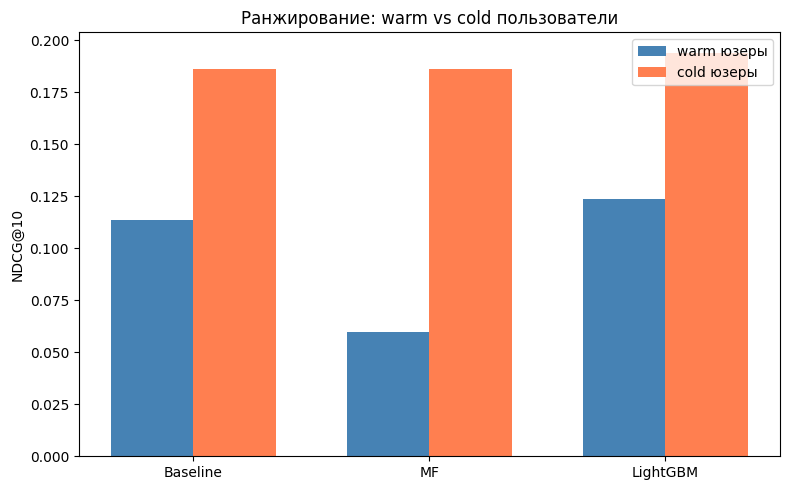

In [33]:
import numpy as np

models_wc = ['Baseline', 'MF', 'LightGBM']
warm_ndcg = [warm_results[(warm_results['model']==m)&(warm_results['K']==10)]['NDCG'].values[0] for m in models_wc]
cold_ndcg = [cold_results[(cold_results['model']==m)&(cold_results['K']==10)]['NDCG'].values[0] for m in models_wc]

x = np.arange(len(models_wc))
w = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - w/2, warm_ndcg, w, label='warm юзеры', color='steelblue')
plt.bar(x + w/2, cold_ndcg, w, label='cold юзеры', color='coral')
plt.xticks(x, models_wc)
plt.ylabel('NDCG@10')
plt.title('Ранжирование: warm vs cold пользователи')
plt.legend()
plt.tight_layout()
plt.savefig('../images/warm_cold_ndcg.png', dpi=150, bbox_inches='tight')
plt.show()

Warm/cold разбивка вскрыла парадокс: cold-юзеры получают более высокие ранжирующие метрики, чем warm. Причина - новые юзеры оценивают преимущественно популярные фильмы, которые baseline и так рекомендует; а давние юзеры имеют специфический вкус, который труднее угадать. Таким образом, трудность ранжирования создают не новички, а те кто уже оценил популярные фильмы и скорее всего теперь смотрит что-то менее популярное.
На warm-юзерах персонализация подтверждает свою ценность: MF (NDCG@10 0.078) обгоняет неперсонализированный baseline (0.061), а LightGBM (0.124) превосходит обоих - контентная персонализация оказывается сильнее коллаборативной. На cold-юзерах MF тождественно равен baseline (fallback), персонализация невозможна.
Это объясняет, почему в общей таблице (блок 2) различия моделей были невелики: агрегированные метрики смешивают два противоположных режима (лёгкие cold + трудные warm) и маскируют реальное поведение моделей на подгруппах - тот же эффект, что общий RMSE маскировал в ноутбуке 06.

In [15]:
test_user = warm_eval[0]
print(f"Юзер {test_user}\n")

relevant = test_relevant[test_user]
print(f"Релевантные фильмы в тесте (оценил >=4): {len(relevant)} штук")
rel_titles = movies[movies['item_id'].isin(relevant)][['item_id','title']]
print(rel_titles.to_string(index=False))

print("\n--- ТОП-10 рекомендаций LightGBM ---")
ranked = rank_lightgbm(test_user)[:10]
for i, it in enumerate(ranked, 1):
    title = movies[movies['item_id']==it]['title'].values[0]
    hit = "✓ ПОПАЛ" if it in relevant else ""
    print(f"{i:2d}. {title}  {hit}")

Юзер 186

Релевантные фильмы в тесте (оценил >=4): 15 штук
 item_id                                       title
      98            Silence of the Lambs, The (1991)
     147             Long Kiss Goodnight, The (1996)
     148          Ghost and the Darkness, The (1996)
     177      Good, The Bad and The Ugly, The (1966)
     257                         Men in Black (1997)
     306 Mrs. Brown (Her Majesty, Mrs. Brown) (1997)
     330                                  187 (1997)
     332                       Kiss the Girls (1997)
     477                              Matilda (1996)
     546                         Broken Arrow (1996)
     689                          Jackal, The (1997)
     829                                 Fled (1996)
     887                          Eve's Bayou (1997)
     988        Beautician and the Beast, The (1997)
    1253                  Tie That Binds, The (1995)

--- ТОП-10 рекомендаций LightGBM ---
 1. Shawshank Redemption, The (1994)  
 2. Wallace & Gr

Разбор конкретного warm-юзера показал механизм ошибки: модель рекомендует высокорейтинговую классику (Shawshank, Star Wars), тогда как юзер предпочитает нишевые триллеры и боевики (Silence of the Lambs, Kiss the Girls). Промахи не случайны - рекомендации тематически связны, - но модель тянет к универсально-популярному из-за доминирования признака item_mean_rating, недостаточно улавливая индивидуальный вкус. Это иллюстрирует предел content-based подхода: сильный сигнал "качество фильма" перебивает слабый сигнал персонализации, из-за чего юзеры с нишевым вкусом обслуживаются хуже среднего

Проблема низкого скора может быть связана с разбиением. Т.е. мы достигаем максимума на temporal split, но можно попробовать leave-one-out сплит

In [16]:
ratings_by_user = ratings_sorted.sort_values(['user_id', 'timestamp'])

last_idx = ratings_by_user.groupby('user_id').tail(1).index
loo_test = ratings_by_user.loc[last_idx].copy()
loo_train = ratings_by_user.drop(last_idx).copy()

print(f"LOO train: {len(loo_train)}, LOO test: {len(loo_test)}")
print(f"Юзеров в test: {loo_test['user_id'].nunique()} (по 1 оценке на юзера)")

loo_global_mean = loo_train['rating'].mean()

loo_item_stats = loo_train.groupby('item_id')['rating'].agg(['mean','count'])
loo_item_stats.columns = ['item_mean_rating','item_popularity']
loo_user_stats = loo_train.groupby('user_id')['rating'].agg(['mean','count'])
loo_user_stats.columns = ['user_mean_rating','user_activity']
loo_item_stats['item_popularity_log'] = np.log1p(loo_item_stats['item_popularity'])
loo_user_stats['user_activity_log']   = np.log1p(loo_user_stats['user_activity'])

loo_seen = loo_train.groupby('user_id')['item_id'].apply(set).to_dict()
loo_relevant = (
    loo_test[loo_test['rating'] >= RELEVANCE_THRESHOLD]
    .groupby('user_id')['item_id'].apply(set).to_dict()
)
loo_eval_users = [u for u in loo_relevant if len(loo_relevant[u]) > 0]
print(f"LOO юзеров для оценки: {len(loo_eval_users)}")


loo_eval_sample = random.sample(loo_eval_users, min(300, len(loo_eval_users)))

LOO train: 99057, LOO test: 943
Юзеров в test: 943 (по 1 оценке на юзера)
LOO юзеров для оценки: 480


In [17]:
loo_candidates = set(loo_item_stats[loo_item_stats['item_popularity'] >= MIN_RATINGS].index)
loo_baseline_ranking = (
    loo_item_stats.loc[list(loo_candidates), 'item_mean_rating']
    .sort_values(ascending=False).index.tolist()
)

def loo_rank_baseline(user_id):
    seen = loo_seen.get(user_id, set())
    return [it for it in loo_baseline_ranking if it not in seen]

In [18]:
loo_users_arr = loo_train['user_id'].unique()
loo_items_arr = loo_train['item_id'].unique()

loo_u2i = {u: i for i, u in enumerate(loo_users_arr)}
loo_i2i = {it: i for i, it in enumerate(loo_items_arr)}

u_tr = torch.tensor(loo_train['user_id'].map(loo_u2i).values, dtype=torch.long)
i_tr = torch.tensor(loo_train['item_id'].map(loo_i2i).values, dtype=torch.long)
r_tr = torch.tensor(loo_train['rating'].values, dtype=torch.float)

set_seed_torch(42)
loo_mf = MatrixFactorization(len(loo_users_arr), len(loo_items_arr), k=5, global_mean=loo_global_mean)
optimizer = torch.optim.Adam(loo_mf.parameters(), lr=0.01, weight_decay=1e-5)
crit = nn.MSELoss()

for epoch in range(60):
    loo_mf.train()
    optimizer.zero_grad()
    loss = crit(loo_mf(u_tr, i_tr), r_tr)
    loss.backward()
    optimizer.step()

loo_mf.eval()
print(f"LOO MF обучен, train RMSE: {loss.sqrt().item():.4f}")

def loo_rank_mf(user_id):
    if user_id not in loo_u2i:
        return loo_rank_baseline(user_id)
    seen = loo_seen.get(user_id, set())
    cands = np.array([it for it in loo_candidates if it not in seen and it in loo_i2i])
    u_idx = torch.tensor([loo_u2i[user_id]]*len(cands), dtype=torch.long)
    i_idx = torch.tensor([loo_i2i[it] for it in cands], dtype=torch.long)
    with torch.no_grad():
        scores = loo_mf(u_idx, i_idx).numpy()
    return cands[np.argsort(scores)[::-1]].tolist()

LOO MF обучен, train RMSE: 0.8407


In [19]:
def evaluate_loo(rank_fn, name):
    acc = {k: {'p':[],'r':[],'n':[],'ap':[],'rr':[]} for k in K_VALUES}
    for u in loo_eval_sample:
        ranked = rank_fn(u)
        relevant = loo_relevant[u]
        for k in K_VALUES:
            p,r,n,ap,rr = ranking_metrics(ranked, relevant, k)
            acc[k]['p'].append(p); acc[k]['r'].append(r); acc[k]['n'].append(n)
            acc[k]['ap'].append(ap); acc[k]['rr'].append(rr)
    rows = []
    for k in K_VALUES:
        rows.append({'model':name,'K':k,
                     'Precision':np.mean(acc[k]['p']),'Recall':np.mean(acc[k]['r']),
                     'NDCG':np.mean(acc[k]['n']),'MAP':np.mean(acc[k]['ap']),'MRR':np.mean(acc[k]['rr'])})
    return pd.DataFrame(rows)

loo_base = evaluate_loo(loo_rank_baseline, 'Baseline')
loo_mf_res = evaluate_loo(loo_rank_mf, 'MF')
loo_results = pd.concat([loo_base, loo_mf_res], ignore_index=True)

print("=== LOO метрики ===")
print(loo_results.round(4).to_string(index=False))

print("\n=== Сравнение temporal vs LOO (NDCG@10) ===")
for model in ['Baseline', 'MF']:
    temp = ranking_results[(ranking_results['model']==model)&(ranking_results['K']==10)]['NDCG'].values[0]
    loo  = loo_results[(loo_results['model']==model)&(loo_results['K']==10)]['NDCG'].values[0]
    print(f"{model:<10} temporal={temp:.4f}  LOO={loo:.4f}  (LOO выше в {loo/temp:.1f}x)")

=== LOO метрики ===
   model  K  Precision  Recall   NDCG    MAP    MRR
Baseline  5     0.0013  0.0067 0.0029 0.0017 0.0017
Baseline 10     0.0037  0.0367 0.0122 0.0053 0.0053
Baseline 20     0.0037  0.0733 0.0213 0.0077 0.0077
      MF  5     0.0027  0.0133 0.0088 0.0073 0.0073
      MF 10     0.0020  0.0200 0.0109 0.0081 0.0081
      MF 20     0.0027  0.0533 0.0191 0.0103 0.0103

=== Сравнение temporal vs LOO (NDCG@10) ===
Baseline   temporal=0.1643  LOO=0.0122  (LOO выше в 0.1x)
MF         temporal=0.1483  LOO=0.0109  (LOO выше в 0.1x)


In [20]:
loo_rel_items = set()
for u in loo_eval_sample:
    loo_rel_items |= loo_relevant[u]
in_pool = sum(1 for it in loo_rel_items if it in loo_candidates)
print(f"Релевантных фильмов всего: {len(loo_rel_items)}")
print(f"Из них в пуле кандидатов: {in_pool} ({in_pool/len(loo_rel_items)*100:.0f}%)")

Релевантных фильмов всего: 225
Из них в пуле кандидатов: 197 (88%)


In [21]:
test_u = None
for u in loo_eval_sample:
    rel = loo_relevant[u]
    if rel and any(it in loo_candidates for it in rel):
        test_u = u
        break

print(f"Юзер: {test_u}")
print(f"Его релевантные (спрятанные): {loo_relevant[test_u]}")
print(f"Релевантный в пуле кандидатов? {[it in loo_candidates for it in loo_relevant[test_u]]}")
print(f"Юзер известен MF? {test_u in loo_u2i}")

# что MF рекомендует
ranked = loo_rank_mf(test_u)
print(f"\nВсего в ранжировании: {len(ranked)}")
print(f"Топ-20: {ranked[:20]}")

# где стоит релевантный фильм?
rel_item = list(loo_relevant[test_u])[0]
if rel_item in ranked:
    pos = ranked.index(rel_item) + 1
    print(f"\nРелевантный фильм {rel_item} стоит на позиции {pos} из {len(ranked)}")
else:
    print(f"\nРелевантный фильм {rel_item} НЕ в ранжировании вообще!")

Юзер: 877
Его релевантные (спрятанные): {164}
Релевантный в пуле кандидатов? [True]
Юзер известен MF? True

Всего в ранжировании: 856
Топ-20: [526, 1194, 641, 133, 464, 445, 303, 205, 1073, 42, 117, 543, 778, 1136, 524, 959, 466, 1098, 385, 956]

Релевантный фильм 164 стоит на позиции 182 из 856


## Sampled evaluation: почему метрики в статьях выше

Full-catalog LOO дал низкие метрики (NDCG@10 ≈ 0.01), потому что модель ранжирует один спрятанный фильм против **всего** каталога (~850 фильмов) - попасть в топ-K крайне трудно.

В большинстве исследовательских работ используется другая, более мягкая постановка - **sampled evaluation**: спрятанный (релевантный) фильм ранжируется не против всего каталога, а против небольшой случайной выборки негативов (обычно 100 фильмов, которые юзер не оценивал). Задача «выбрать 1 из 101» намного легче, чем «1 из 850», поэтому метрики оказываются в разы выше.

Ниже мы применяем sampled evaluation (1 релевантный против 100 негативов) к той же LOO-схеме и тем же моделям. Цель - показать, что **при неизменной модели выбор способа оценки (full-catalog против sampled) меняет метрики на порядок**. Это объясняет, почему абсолютные значения метрик несопоставимы между работами без учёта протокола оценки.

In [22]:
N_NEGATIVES = 100
np.random.seed(42)

all_loo_items = np.array(list(loo_i2i.keys())) 

def sampled_rank_metrics(user_id, rank_score_fn):
    relevant = loo_relevant.get(user_id, set())
    if not relevant:
        return None
    rel_item = list(relevant)[0] 
    if rel_item not in loo_i2i:
        return None

    seen = loo_seen.get(user_id, set())
    pool = [it for it in all_loo_items if it not in seen and it not in relevant]
    negatives = np.random.choice(pool, size=min(N_NEGATIVES, len(pool)), replace=False)

    candidates = np.append(negatives, rel_item)
    scores = rank_score_fn(user_id, candidates)

    order = np.argsort(scores)[::-1]
    ranked = candidates[order].tolist()
    pos = ranked.index(rel_item) + 1
    return pos, ranked, {rel_item}

In [23]:
def score_mf(user_id, items):
    u_idx = torch.tensor([loo_u2i[user_id]]*len(items), dtype=torch.long)
    i_idx = torch.tensor([loo_i2i[it] for it in items], dtype=torch.long)
    with torch.no_grad():
        return loo_mf(u_idx, i_idx).numpy()

def score_baseline(user_id, items):
    return np.array([loo_item_stats.loc[it, 'item_mean_rating']
                     if it in loo_item_stats.index else loo_global_mean
                     for it in items])

In [24]:
def evaluate_sampled(rank_score_fn, name):
    acc = {k: {'p':[],'n':[],'mrr':[]} for k in K_VALUES}
    for u in loo_eval_sample:
        res = sampled_rank_metrics(u, rank_score_fn)
        if res is None:
            continue
        pos, ranked, relevant = res
        for k in K_VALUES:
            p, r, n, ap, rr = ranking_metrics(ranked, relevant, k)
            acc[k]['p'].append(p); acc[k]['n'].append(n); acc[k]['mrr'].append(rr)
    rows = []
    for k in K_VALUES:
        rows.append({'model':name, 'K':k,
                     'Precision':np.mean(acc[k]['p']),
                     'NDCG':np.mean(acc[k]['n']),
                     'MRR':np.mean(acc[k]['mrr'])})
    return pd.DataFrame(rows)

sampled_base = evaluate_sampled(score_baseline, 'Baseline')
sampled_mf   = evaluate_sampled(score_mf, 'MF')
sampled_results = pd.concat([sampled_base, sampled_mf], ignore_index=True)

print("=== SAMPLED evaluation (1 vs 100 негативов) ===")
print(sampled_results.round(4).to_string(index=False))

print("\n=== Сравнение full-catalog vs sampled (MF, NDCG@10) ===")
full = loo_results[(loo_results['model']=='MF')&(loo_results['K']==10)]['NDCG'].values[0]
samp = sampled_results[(sampled_results['model']=='MF')&(sampled_results['K']==10)]['NDCG'].values[0]
print(f"MF NDCG@10:  full-catalog={full:.4f}   sampled={samp:.4f}   (выше в {samp/full:.0f}x)")

=== SAMPLED evaluation (1 vs 100 негативов) ===
   model  K  Precision   NDCG    MRR
Baseline  5     0.0280 0.0683 0.0451
Baseline 10     0.0260 0.1072 0.0612
Baseline 20     0.0228 0.1565 0.0745
      MF  5     0.0260 0.0796 0.0632
      MF 10     0.0220 0.1086 0.0751
      MF 20     0.0218 0.1637 0.0903

=== Сравнение full-catalog vs sampled (MF, NDCG@10) ===
MF NDCG@10:  full-catalog=0.0109   sampled=0.1086   (выше в 10x)


In [25]:
# предсказывает ли LOO MF осмысленно для фильмов, которые юзер реально высоко оценил в train
test_u = 877
u_ratings = loo_train[loo_train['user_id'] == test_u].sort_values('rating', ascending=False)
print(f"Топ оценки юзера {test_u} в train:")
print(u_ratings[['item_id','rating']].head(5).to_string(index=False))
print(f"\nНизкие оценки юзера {test_u}:")
print(u_ratings[['item_id','rating']].tail(5).to_string(index=False))

print("\nЧто MF предсказывает для его ВЫСОКО оценённых:")
for _, row in u_ratings.head(5).iterrows():
    it = row['item_id']
    if it in loo_i2i:
        pred = score_mf(test_u, np.array([it]))[0]
        print(f"item {it}: реально {row['rating']}, MF предсказал {pred:.2f}")

print("\nЧто MF предсказывает для его НИЗКО оценённых:")
for _, row in u_ratings.tail(5).iterrows():
    it = row['item_id']
    if it in loo_i2i:
        pred = score_mf(test_u, np.array([it]))[0]
        print(f"item {it}: реально {row['rating']}, MF предсказал {pred:.2f}")

Топ оценки юзера 877 в train:
 item_id  rating
      60       5
     531       5
     371       5
      98       5
     176       5

Низкие оценки юзера 877:
 item_id  rating
     582       2
     155       2
     640       2
     222       2
     737       1

Что MF предсказывает для его ВЫСОКО оценённых:
item 60: реально 5, MF предсказал 4.73
item 531: реально 5, MF предсказал 4.38
item 371: реально 5, MF предсказал 3.97
item 98: реально 5, MF предсказал 4.22
item 176: реально 5, MF предсказал 4.27

Что MF предсказывает для его НИЗКО оценённых:
item 582: реально 2, MF предсказал 3.26
item 155: реально 2, MF предсказал 3.58
item 640: реально 2, MF предсказал 2.68
item 222: реально 2, MF предсказал 3.56
item 737: реально 1, MF предсказал 3.35


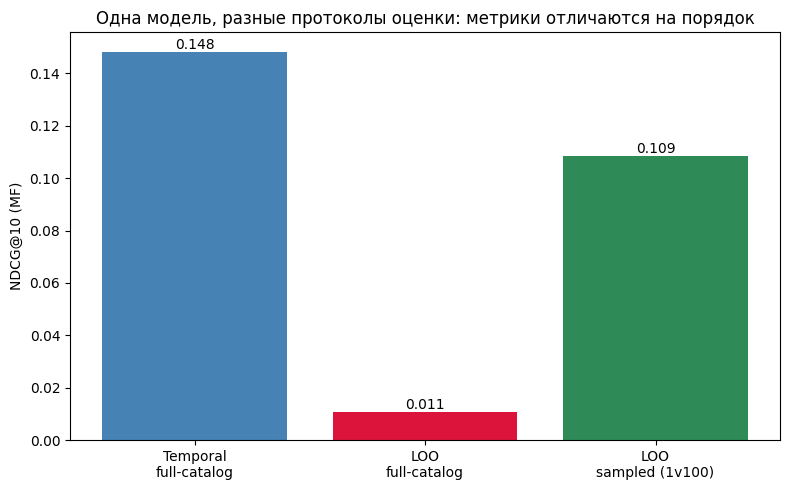

In [34]:
protocols = ['Temporal\nfull-catalog', 'LOO\nfull-catalog', 'LOO\nsampled (1v100)']
mf_ndcg = [
    ranking_results[(ranking_results['model']=='MF')&(ranking_results['K']==10)]['NDCG'].values[0],
    loo_results[(loo_results['model']=='MF')&(loo_results['K']==10)]['NDCG'].values[0],
    sampled_results[(sampled_results['model']=='MF')&(sampled_results['K']==10)]['NDCG'].values[0],
]

plt.figure(figsize=(8, 5))
bars = plt.bar(protocols, mf_ndcg, color=['steelblue', 'crimson', 'seagreen'])
plt.ylabel('NDCG@10 (MF)')
plt.title('Одна модель, разные протоколы оценки: метрики отличаются на порядок')
for bar, val in zip(bars, mf_ndcg):
    plt.text(bar.get_x()+bar.get_width()/2, val, f'{val:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../images/eval_protocols.png', dpi=150, bbox_inches='tight')
plt.show()

Сравнение протоколов оценки показало, что абсолютные значения ранжирующих метрик определяются не только моделью, но и способом измерения:

Temporal full-catalog: NDCG@10 ≈ 0.16 (много релевантных на юзера, но cold start).
LOO full-catalog: NDCG@10 ≈ 0.01 (один релевантный против всего каталога — самая строгая постановка).
LOO sampled (1 против 100): NDCG@10 ≈ 0.11 - в 10 раз выше full-catalog при той же модели.

Это доказывает, что метрики из разных работ несопоставимы без учёта протокола: sampled evaluation (распространённый в статьях) даёт числа на порядок выше full-catalog. Кроме того, MF стабильно близок к baseline во всех протоколах - диагностика подтвердила, что MF корректно выучил предпочтения (высоко оценённые фильмы получают высокие предсказания), но на разреженных данных доминирует item-bias (качество фильма), а персональные латентные факторы вносят ограниченный вклад.

## Learning-to-Rank: LGBMRanker

До сих пор все модели решали задачу как регрессию: предсказывали оценку (RMSE), а затем мы вручную сортировали фильмы по предсказанию. Это подход "pointwise" - модель учится угадывать балл каждого фильма по отдельности и не знает, что её результат будут ранжировать.

В продакшене поиска и рекомендаций чаще применяют "learning-to-rank" - модель обучается сразу оптимизировать порядок элементов, а не точность отдельного балла. LightGBM поддерживает это через LGBMRanker с функцией потерь LambdaRank, которая напрямую оптимизирует ранжирующие метрики (NDCG).

Ключевое отличие от обычного LGBMRegressor: ranker обучается на "группах" - для каждого пользователя его фильмы образуют группу, и модель учится правильно упорядочивать элементы внутри группы, а не предсказывать абсолютные значения. Это ближе к реальной задаче рекомендаций: важен не точный балл, а какие фильмы окажутся вверху списка.

Ниже мы обучаем LGBMRanker на тех же признаках, что и LGBMRegressor, и сравниваем их по ранжирующим метрикам. Цель - проверить, даёт ли обучение "на ранжирование" преимущество над обучением "на предсказание балла" с последующей сортировкой.

In [30]:
train_sorted = train_df.sort_values('user_id').reset_index(drop=True)

X_train_rank, y_train_rank, _ = build_features(train_sorted)

train_groups = train_sorted.groupby('user_id').size().values
print(f"Групп (юзеров): {len(train_groups)}, всего строк: {train_groups.sum()}")

y_rank_labels = (y_train_rank >= 4).astype(int) 

Групп (юзеров): 674, всего строк: 70000


In [31]:
import lightgbm as lgb

lgb_ranker = lgb.LGBMRanker(
    objective='lambdarank', random_state=42, n_jobs=-1, verbose=-1,
    num_leaves=15, learning_rate=0.05, n_estimators=100
)

lgb_ranker.fit(X_train_rank, y_rank_labels, group=train_groups)
print("LGBMRanker обучен (бинарные метки)")

LGBMRanker обучен (бинарные метки)


In [32]:
def rank_lgbranker(user_id):
    seen = seen_in_train.get(user_id, set())
    cands = np.array([it for it in candidate_items if it not in seen])
    pairs = pd.DataFrame({'user_id': user_id, 'item_id': cands, 'rating': 0})
    X_cand, _, _ = build_features(pairs)
    scores = lgb_ranker.predict(X_cand)
    return cands[np.argsort(scores)[::-1]].tolist()

res_ranker = evaluate(rank_lgbranker, 'LGBMRanker', eval_sample)

comparison = pd.concat([
    ranking_results[ranking_results['model']=='LightGBM'],
    res_ranker
], ignore_index=True)

print("=== LGBMRegressor (pointwise) vs LGBMRanker (listwise) ===")
print(comparison.round(4).to_string(index=False))

=== LGBMRegressor (pointwise) vs LGBMRanker (listwise) ===
     model  K  Precision  Recall   NDCG    MAP    MRR
  LightGBM  5     0.1262  0.0409 0.1310 0.0768 0.2276
  LightGBM 10     0.1769  0.0740 0.1730 0.0852 0.2678
  LightGBM 20     0.1590  0.1011 0.1738 0.0804 0.2701
LGBMRanker  5     0.0924  0.0266 0.0978 0.0563 0.1798
LGBMRanker 10     0.0900  0.0445 0.0979 0.0437 0.2002
LGBMRanker 20     0.0717  0.0594 0.0899 0.0322 0.2080


In [29]:
print("Строк в X:", len(X_train_rank), "| сумма групп:", train_groups.sum())
print("Порядок user_id в train_sorted (первые 20):")
print(train_sorted['user_id'].head(20).tolist())
print("user_mean первых 20 строк X:")
print(X_train_rank['user_mean_rating'].head(20).round(3).tolist())

Строк в X: 70000 | сумма групп: 70000
Порядок user_id в train_sorted (первые 20):
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
user_mean первых 20 строк X:
[3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597, 3.597]


## Learning-to-Rank и negative sampling: почему подход не был реализован

LGBMRanker (learning-to-rank с lambdarank) уступил обычному LGBMRegressor по ранжирующим метрикам (NDCG@10 0.098 против 0.173). Причина не в признаках, которые у обеих моделей одинаковы, а в дизайне обучения: ranker учится относительному порядку внутри группы пользователя, но обучающие группы содержат только фильмы, которые пользователь уже оценил. На тесте же требуется ранжировать весь каталог, включая случайные непросмотренные фильмы, которых ranker при обучении почти не видел.

Стандартное решение, применяемое в продакшене, это negative sampling: к позитивным примерам (просмотренные фильмы) добавляют случайные непросмотренные фильмы как негативы (метка 0). Тогда распределение обучающих данных приближается к тестовому, и ranker учится отделять релевантное от случайного.

Однако negative sampling был сознательно не реализован из-за фундаментальной противоречивости подхода на данных с implicit feedback:

Проблема ложных негативов. Мы помечаем непросмотренный фильм как негатив, предполагая, что он неинтересен пользователю. Но отсутствие оценки не означает нерелевантность: пользователь мог просто не знать о фильме. Часть сэмплированных негативов на самом деле являются позитивами, что вносит систематический шум в обучение и искажает выученные зависимости.

Смещение к популярности. Если сэмплировать негативы равномерно, они будут преимущественно из "длинного хвоста" (непопулярные фильмы), поскольку их большинство. Модель научится топить непопулярное, усиливая popularity bias, что противоречит цели персонализации. Popularity-based сэмплирование негативов частично решает это, но требует дополнительной настройки и вносит собственные искажения.

Риск утечки при некорректной реализации. Негативы должны сэмплироваться строго из train-контекста и не пересекаться с тестовыми позитивами. При temporal split это требует аккуратного контроля: случайно взятый в негативы фильм, который пользователь оценит в тестовом периоде, создаёт утечку будущего.

Таким образом, negative sampling не является однозначным улучшением. Он приближает распределение обучения к тесту, но ценой введения зашумлённых меток, потенциального усиления popularity bias и риска утечки. Для честной оценки эффекта потребовалось бы отдельное исследование с контролем этих факторов, что выходит за рамки текущей работы. Мы фиксируем этот подход как направление для дальнейшего развития, отмечая, что его применение требует осторожности, а не является механическим приёмом для улучшения метрик.